In [122]:
#Load & Understand Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

import warnings
warnings.filterwarnings("ignore")


In [123]:
df_ipl = pd.read_csv("/content/IPL_Squad_2023_Auction_Dataset.csv")
df_ipl.head()


,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [124]:
df_ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       568 non-null    int64  
 1   Player's List    568 non-null    object 
 2   Base Price       568 non-null    object 
 3   TYPE             568 non-null    object 
 4   COST IN ₹ (CR.)  243 non-null    float64
 5   Cost IN $ (000)  243 non-null    float64
 6   2022 Squad       230 non-null    object 
 7   Team             568 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 35.6+ KB


In [125]:
df_ipl.describe()

,Unnamed: 0,COST IN ₹ (CR.),Cost IN $ (000)
count,568.000000,243.000000,243.000000
mean,283.500000,0.687243,82.469136
std,164.111751,2.511700,301.404032
min,0.000000,0.000000,0.000000
25%,141.750000,0.000000,0.000000
50%,283.500000,0.000000,0.000000
75%,425.250000,0.200000,24.000000
max,567.000000,18.500000,2220.000000


**Data Cleaning and Preprocessing**

In [126]:
#Remove duplicates
df_ipl.duplicated().sum()
df_ipl.drop_duplicates(inplace=True)


In [144]:
# Drop index column
df_ipl.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Create Sold column
df_ipl['Sold'] = df_ipl['COST IN ₹ (CR.)'].notnull()

# Clean Base Price
df_ipl['Base Price'] = df_ipl['Base Price'].astype(str).str.replace('₹','').str.replace(' Cr','').pipe(pd.to_numeric, errors='coerce')

# Price Multiplier
df_ipl['Price Multiplier'] = df_ipl['COST IN ₹ (CR.)'] / df_ipl['Base Price']

# Retention
df_ipl['Retained'] = df_ipl['2022 Squad'] == df_ipl['Team']

In [128]:
#Handle Missing Values
df_ipl.isnull().sum()

# Numerical → median
num_cols = df_ipl.select_dtypes(include=np.number).columns
for col in num_cols:
    df_ipl[col].fillna(df_ipl[col].median(), inplace=True)

# Categorical → mode
cat_cols = df_ipl.select_dtypes(include='object').columns
for col in cat_cols:
    df_ipl[col].fillna(df_ipl[col].mode()[0], inplace=True)


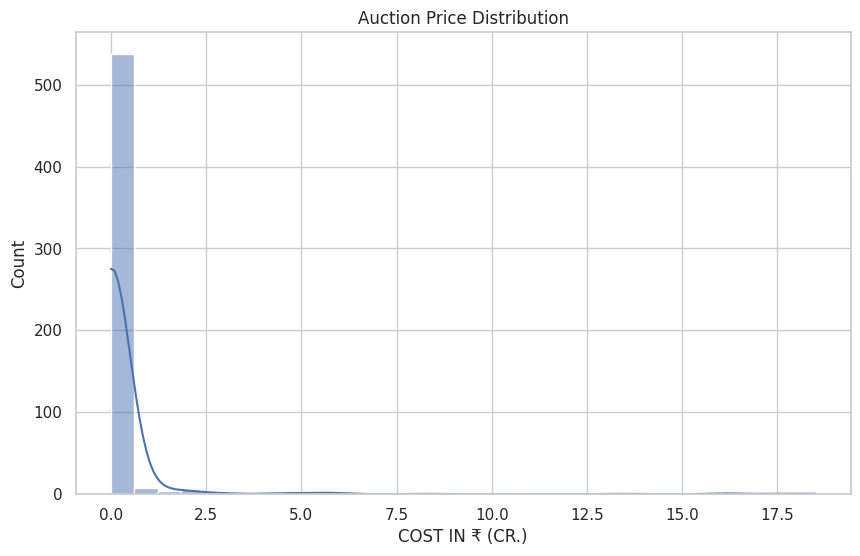

In [129]:
#Auction Price Distribution
sns.histplot(df_ipl['COST IN ₹ (CR.)'], bins=30, kde=True)
plt.title('Auction Price Distribution')
plt.show()

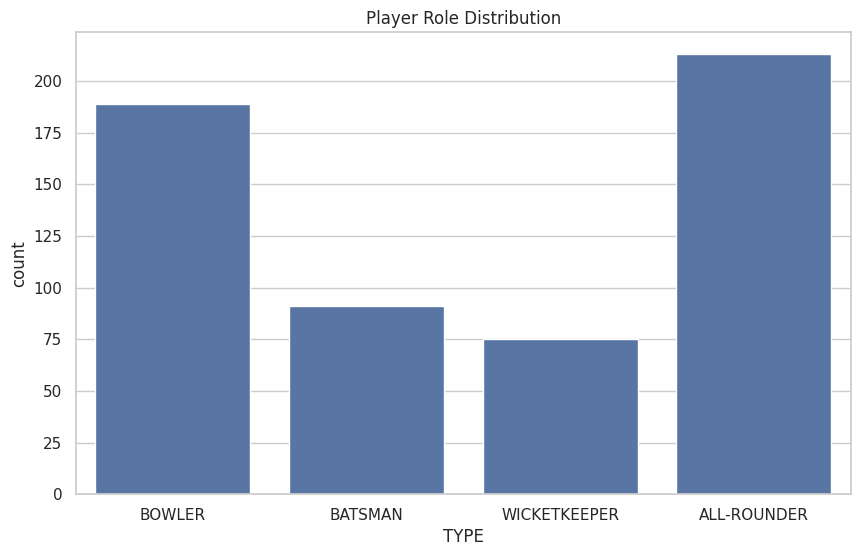

In [130]:
#Player Role Distribution
sns.countplot(x='TYPE', data=df_ipl)
plt.title('Player Role Distribution')
plt.show()

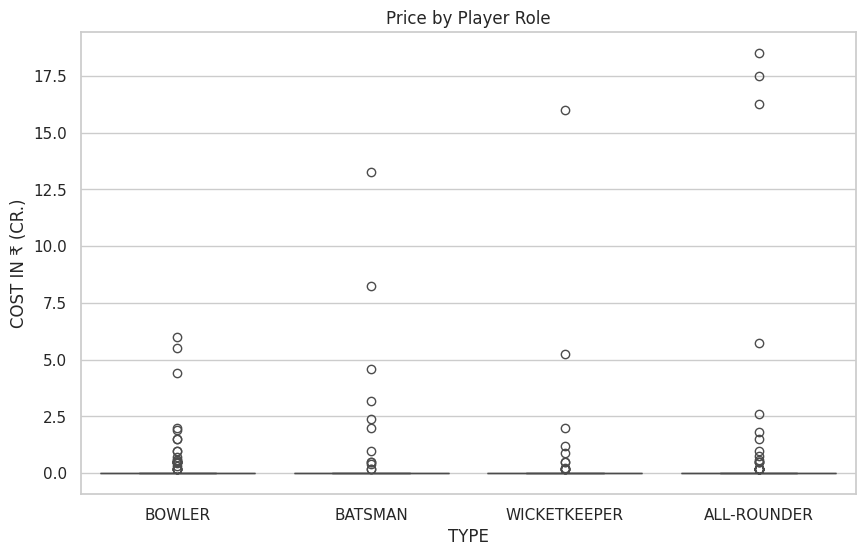

In [131]:
#Price vs Role
sns.boxplot(x='TYPE', y='COST IN ₹ (CR.)', data=df_ipl)
plt.title("Price by Player Role")
plt.show()

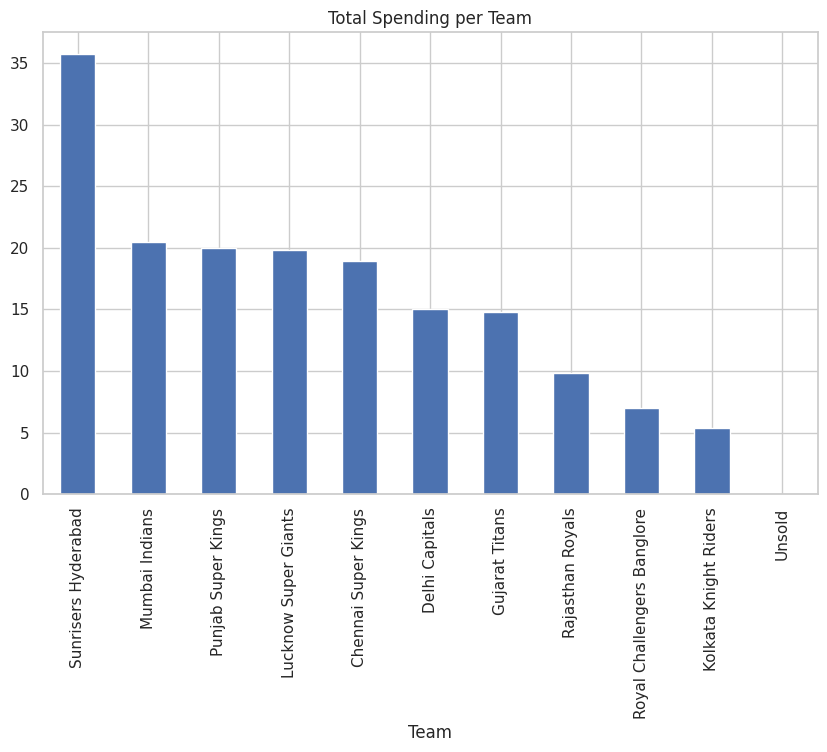

In [132]:
#Price vs Team
team_spending = df_ipl.groupby('Team')['COST IN ₹ (CR.)'].sum().sort_values(ascending=False)
team_spending.plot(kind='bar')
plt.title("Total Spending per Team")
plt.show()

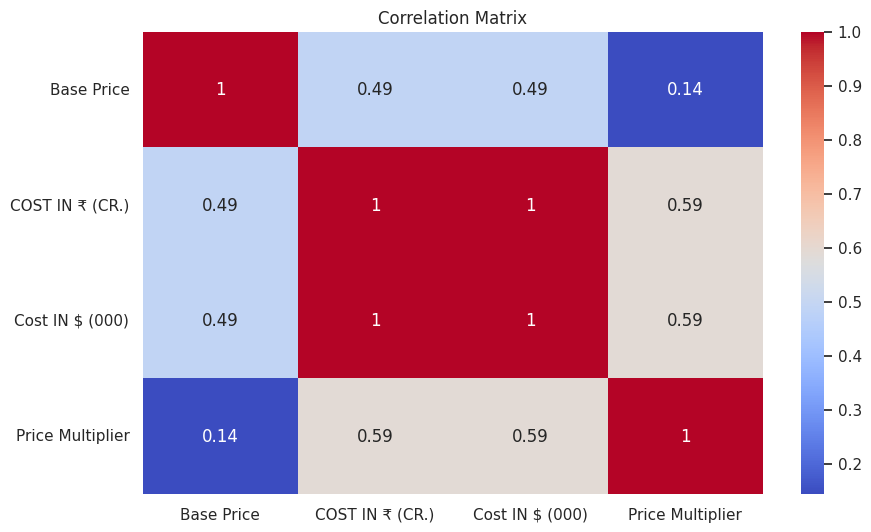

In [133]:
#Correlation Heatmap
df_ipl['Base Price'] = pd.to_numeric(df_ipl['Base Price'], errors='coerce')
corr = df_ipl.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [134]:
#Identify Top Expensive Players
top_players = df_ipl.sort_values(by='COST IN ₹ (CR.)', ascending=False).head(10)
print(top_players[['Player\'s List', 'Team', 'TYPE', 'COST IN ₹ (CR.)']])

        Player's List                  Team          TYPE  COST IN ₹ (CR.)
97         Sam Curran    Punjab Super Kings   ALL-ROUNDER            18.50
144     Cameron Green        Mumbai Indians   ALL-ROUNDER            17.50
25         Ben Stokes   Chennai Super Kings   ALL-ROUNDER            16.25
119   Nicholas Pooran  Lucknow Super Giants  WICKETKEEPER            16.00
218       Harry Brook   Sunrisers Hyderabad       BATSMAN            13.25
219    Mayank Agarwal   Sunrisers Hyderabad       BATSMAN             8.25
0         Shivam Mavi        Gujarat Titans        BOWLER             6.00
193      Jason Holder      Rajasthan Royals   ALL-ROUNDER             5.75
50       Mukesh Kumar        Delhi Capitals        BOWLER             5.50
220  Heinrich Klaasen   Sunrisers Hyderabad  WICKETKEEPER             5.25


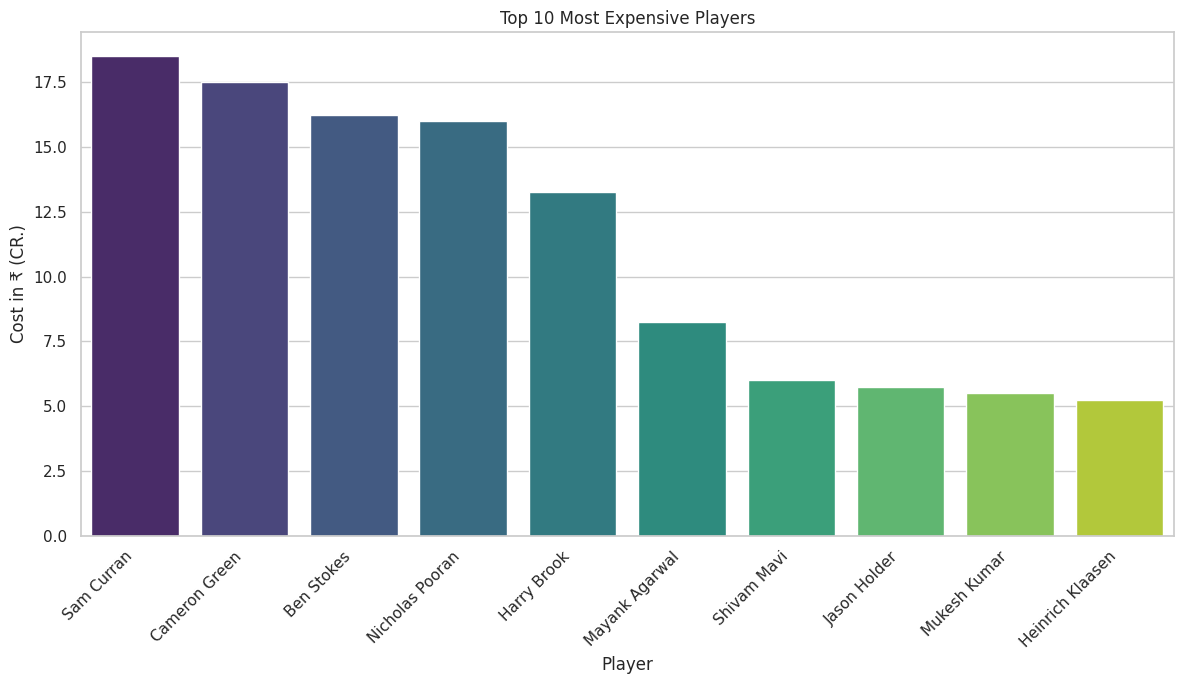

In [135]:
# Visualize Top Expensive Players
plt.figure(figsize=(12, 7))
sns.barplot(x='Player\'s List', y='COST IN ₹ (CR.)', data=top_players, palette='viridis')
plt.title('Top 10 Most Expensive Players')
plt.xlabel('Player')
plt.ylabel('Cost in ₹ (CR.)')
plt.xticks(rotation=45, ha='right') # Rotate player names for better readability
plt.tight_layout()
plt.show()

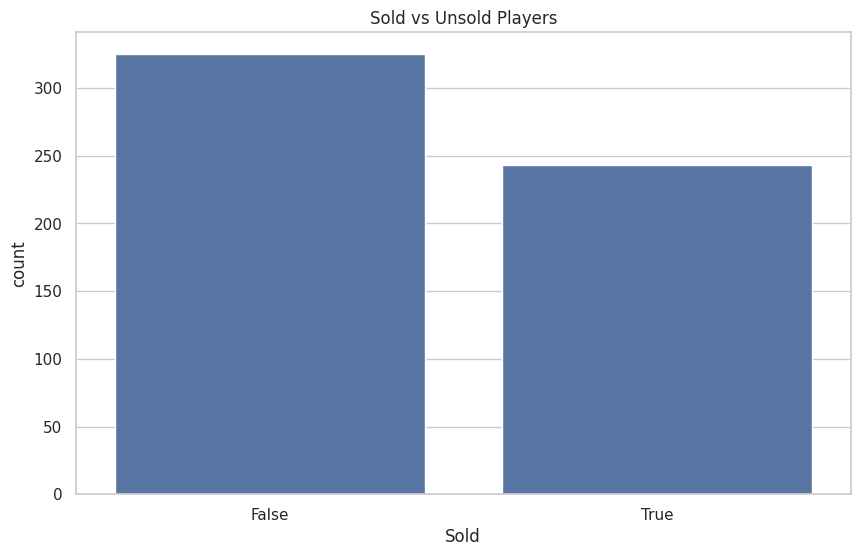

In [136]:
#Sold vs Unsold Distribution
sns.countplot(x='Sold', data=df_ipl)
plt.title("Sold vs Unsold Players")
plt.show()

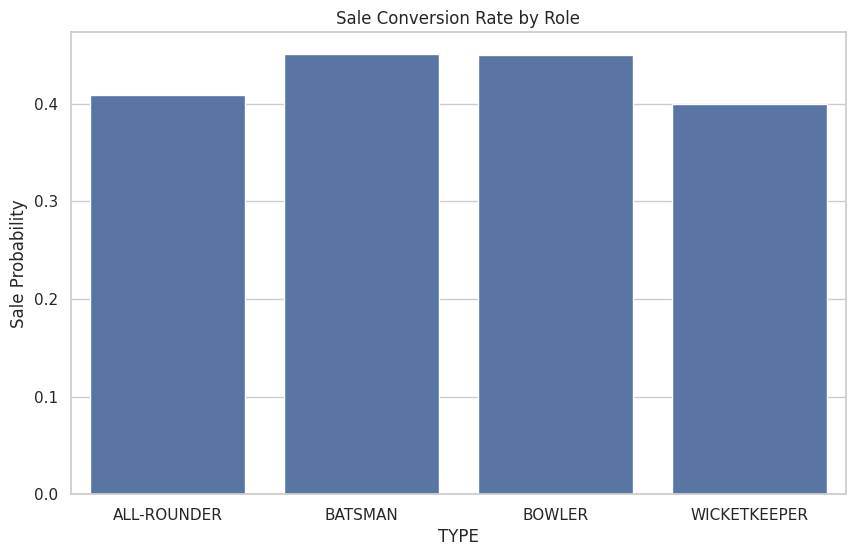

In [137]:
#Sale Conversion Rate by Role
conversion = df_ipl.groupby('TYPE')['Sold'].mean().reset_index()

sns.barplot(x='TYPE', y='Sold', data=conversion)
plt.title("Sale Conversion Rate by Role")
plt.ylabel("Sale Probability")
plt.show()

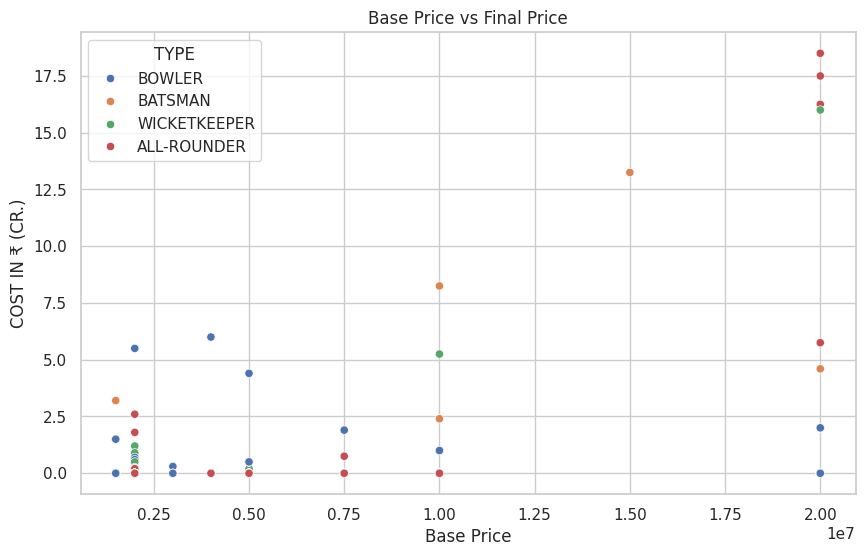

In [138]:
#Base Price vs Final Price
sns.scatterplot(x='Base Price', y='COST IN ₹ (CR.)', hue='TYPE', data=df_ipl)
plt.title("Base Price vs Final Price")
plt.show()

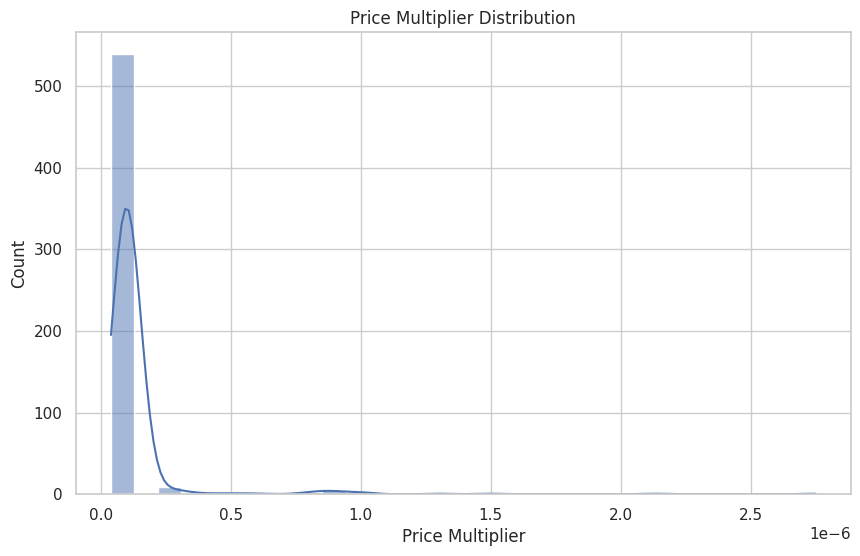

In [139]:
#Price Multiplier Distribution
sns.histplot(df_ipl['Price Multiplier'].dropna(), bins=30, kde=True)
plt.title("Price Multiplier Distribution")
plt.show()

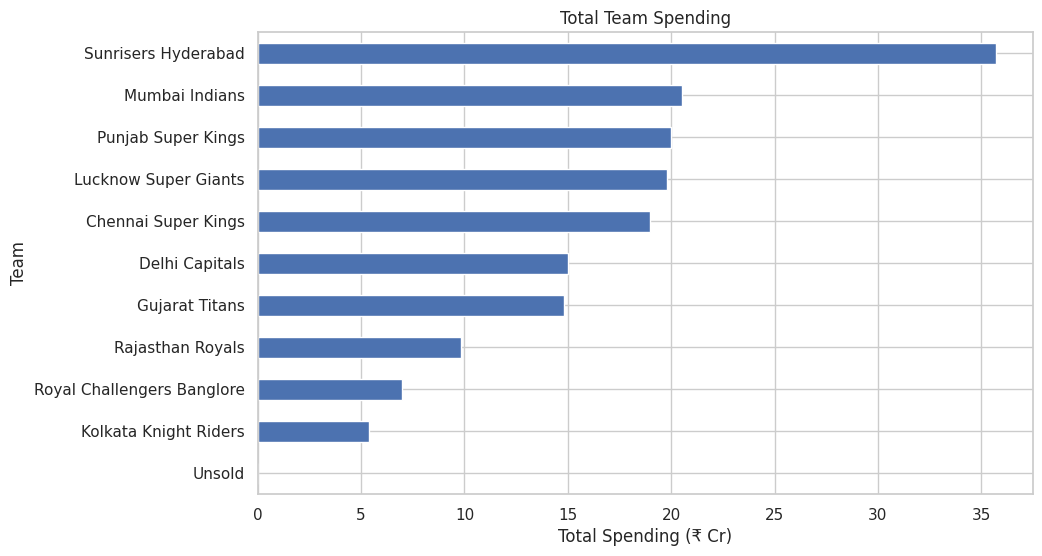

In [140]:
#Team Spending Comparison
team_spend = df_ipl.groupby('Team')['COST IN ₹ (CR.)'].sum().sort_values()

team_spend.plot(kind='barh')
plt.title("Total Team Spending")
plt.xlabel("Total Spending (₹ Cr)")
plt.show()

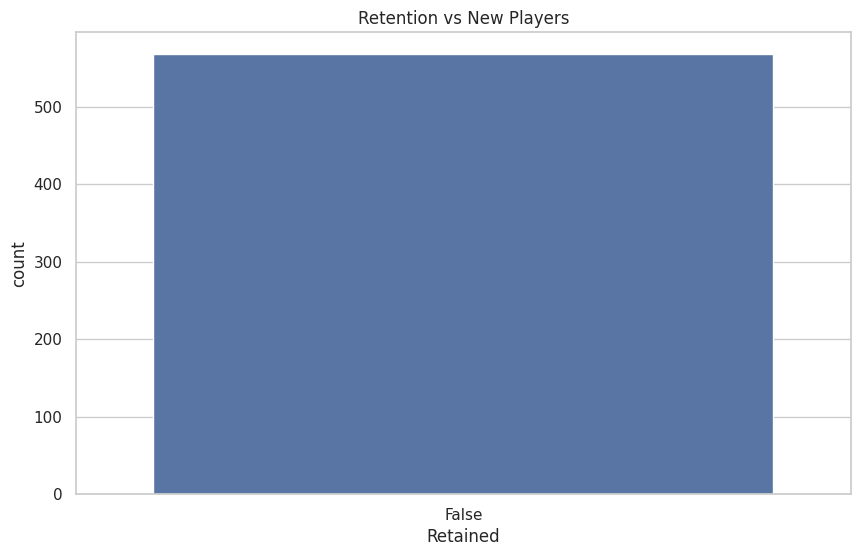

In [141]:
#Retention Strategy Visualization
sns.countplot(x='Retained', data=df_ipl)
plt.title("Retention vs New Players")
plt.show()

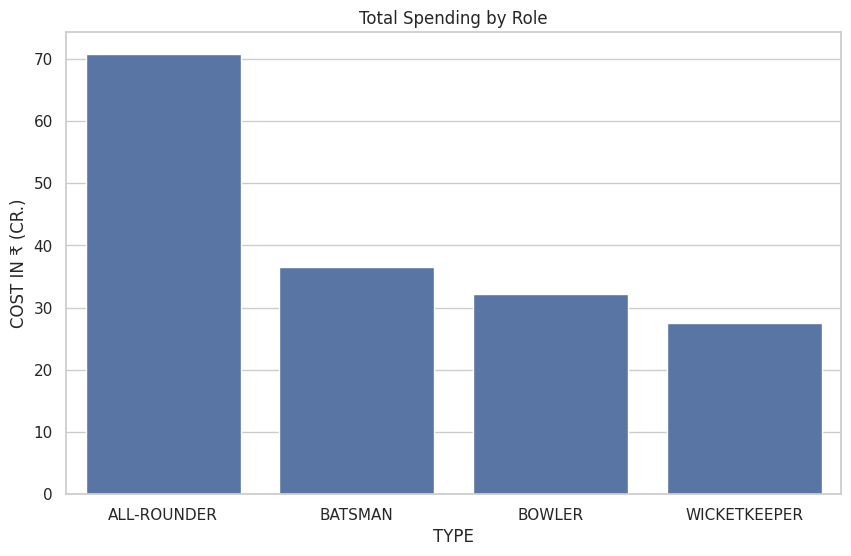

In [142]:
#Role-wise Spending Intensity
role_spend = df_ipl.groupby('TYPE')['COST IN ₹ (CR.)'].sum().reset_index()

sns.barplot(x='TYPE', y='COST IN ₹ (CR.)', data=role_spend)
plt.title("Total Spending by Role")
plt.show()

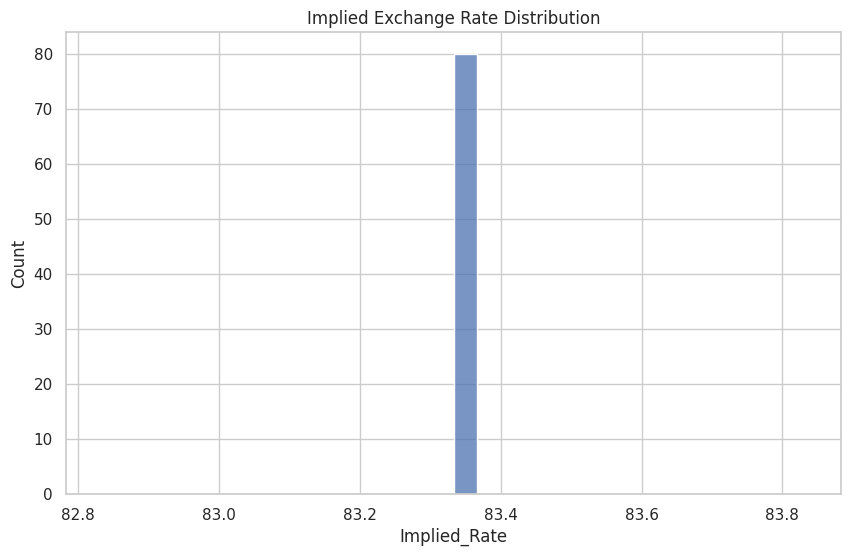

In [143]:
#Currency Consistency Check (₹ vs $)
df_ipl['Implied_Rate'] = (df_ipl['COST IN ₹ (CR.)'] * 10_000_000) / (df_ipl['Cost IN $ (000)'] * 1000)

sns.histplot(df_ipl['Implied_Rate'].dropna(), bins=30)
plt.title("Implied Exchange Rate Distribution")
plt.show()

**Recommendations**


1️- Optimize Base Price Strategy

High unsold rate suggests base prices may be inflated in certain roles.
→ Adjust base prices based on historical sale conversion rates per role.

2️-Target High Multiplier Players

Players with high price multipliers indicate strong market demand.
→ Invest more in profiles that historically generate bidding competition.

3️-Focus on High-Conversion Roles

Roles with higher sale probability represent stronger demand.
→ Allocate scouting and analytics budget toward high-demand player types.

4️-Improve Team Budget Balance

Spending inequality across teams suggests risk concentration.
→ Avoid over-reliance on few expensive players; diversify squad investments.

5️- Strengthen Retention Strategy

Retention patterns reveal team stability vs rebuilding behavior.
→ Maintain a balanced mix of retained core players and strategic acquisitions.

6️- Monitor Currency & Financial Consistency

Ensure pricing consistency across ₹ and $ valuations to avoid financial misreporting or inefficiencies.